# Hyperparameter Tuning (Ray Tune)

<div style="text-align: justify">

The following notebook is dedicated to <b>hyperparameter optimisation</b> for the <b>Tau Anomaly Detection</b> analysis. Using <b>Ray Tune</b> with the <b>ASHA scheduler</b> for aggressive early stopping, a search is performed over the hyperparameter space for the autoencoder (AE) or variational autoencoder (VAE). Models are trained on <b>background only</b> using PyTorch Lightning, and the best configuration is exported as a Hydra-compatible YAML config.

</div>

## Pipeline Summary

| Step | Module | Description |
|------|--------|-------------|
| Config | `hydra.compose` | Load analysis, model, and tuning configuration |
| Load | `io.load_dataframe` | Read mc.parquet from feature engineering output |
| Subsample | `DataFrame.sample` | Optional stratified subsampling to speed up tuning |
| Search Space | `tuning.build_search_space` | Build Ray Tune search space from config |
| Tune | `tuning.run_tune` | Run Ray Tune with ASHA scheduler and Lightning training |
| Results | — | Best trial summary, trial dataframe, and diagnostic plots |
| Export | `tuning.export_best_config` | Save best config as Hydra-compatible YAML |

The same pipeline is available as a CLI via `python run.py stage=tune` or `make tune`.

## Initialization

### Libraries

Configuration:
* [Hydra](https://hydra.cc/)
* [OmegaConf](https://omegaconf.readthedocs.io/)
* [pyrootutils](https://github.com/ashleve/pyrootutils)

Data Processing:
* [Pandas](https://pandas.pydata.org/)

Hyperparameter Optimisation:
* [Ray Tune](https://docs.ray.io/en/latest/tune/index.html)

Machine Learning:
* [PyTorch](https://pytorch.org/)
* [PyTorch Lightning](https://lightning.ai/docs/pytorch/stable/)
* [scikit-learn](https://scikit-learn.org/stable/)

Data Visualization:
* [Matplotlib](https://matplotlib.org/)

### Notebook

Activating autoreload of imported modules.

In [1]:
%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = "retina"

Initializing the project root.

In [2]:
import pyrootutils

path = pyrootutils.setup_root(
    search_from=__file__ if "__file__" in locals() else ".",
    indicator=".gitignore",
    pythonpath=True,
)

Suppressing unessential warnings and applying ATLAS style.

In [3]:
from src.utils import suppress_warnings
from src.visualization.plots import apply_atlas_style

suppress_warnings()
apply_atlas_style()

## Configuration

Loading the Hydra configuration.

> **Model selection:** change `overrides` to `["model=vae"]` for VAE tuning.

In [4]:
from hydra import compose, initialize_config_dir

initialize_config_dir(config_dir=str(path / "configs"), version_base="1.3")
cfg = compose(config_name="config", overrides=["model=ae"])

Resolving input and output directories from config.

In [5]:
from src.processing.analysis import get_output_paths

output_paths = get_output_paths(cfg)
dataframes_dir = path / output_paths["dataframes_dir"]
models_dir = path / output_paths["models_dir"]

model_type = cfg.model.name
plots_dir = path / output_paths["plots_dir"] / f"{model_type}_tuning"

models_dir.mkdir(parents=True, exist_ok=True)
plots_dir.mkdir(parents=True, exist_ok=True)

## Data Loading & Preparation

Loading the MC DataFrame produced by the feature engineering pipeline.

In [6]:
from src.processing.io import load_dataframe

df_mc = load_dataframe(dataframes_dir / "mc.parquet")
print(f"Loaded: {len(df_mc):,} events, {len(df_mc.columns)} columns")

Loaded: 9,827,169 events, 57 columns


Optionally subsampling the dataset (stratified by sample type) to speed up tuning.

In [7]:
subsample = cfg.tuning.get("subsample_fraction", 1.0)
if subsample < 1.0:
    df_mc = df_mc.groupby("sample_type", group_keys=False).sample(
        frac=subsample, random_state=cfg.seed
    )
    print(f"Subsampled to {subsample:.0%}: {len(df_mc):,} events")
else:
    print("Using full dataset (no subsampling)")

Subsampled to 10%: 982,717 events


## Search Space

Search space defined in `configs/tuning/default.yaml` with separate entries for AE and VAE.

In [8]:
from src.models.tuning import build_search_space

search_space = build_search_space(cfg.tuning, model_type)
print(f"Model type: {model_type}")
print(f"Search space parameters: {list(search_space.keys())}")

Model type: ae
Search space parameters: ['n_layers', 'layer_size', 'latent_dim', 'dropout', 'learning_rate', 'weight_decay', 'batch_size']


## Ray Tune Search

Running Ray Tune with the ASHA scheduler. Each trial trains on the background-only split using PyTorch Lightning.

In [9]:
from src.models.tuning import run_tune
from src.processing.analysis import get_background_origins

mc_path = str(dataframes_dir / "mc.parquet")
background_origins = get_background_origins(cfg)

dm_kwargs = {
    "mc_path": mc_path,
    "background_origins": background_origins,
    "normalization": cfg.model.normalization,
    "val_fraction": cfg.pipeline.val_fraction,
    "batch_size": cfg.model.batch_size,
    "seed": cfg.seed,
    "subsample_fraction": cfg.tuning.subsample_fraction,
}

best_config, trial_df = run_tune(cfg=cfg, dm_kwargs=dm_kwargs)
print("Tuning complete")

Tuning complete


## Results

### Best Trial Summary

In [10]:
n_completed = len(trial_df.dropna(subset=["val_loss"]))
n_early_stopped = len(trial_df) - n_completed

print(f"Completed: {n_completed} | Early-stopped (ASHA): {n_early_stopped}")

print(f"\nBest config:")
for k, v in best_config.items():
    print(f"  {k}: {v}")

Completed: 100 | Early-stopped (ASHA): 0

Best config:
  n_layers: 2
  layer_size: 128
  latent_dim: 32
  dropout: 0.038339382583836346
  learning_rate: 0.0007071759710220261
  weight_decay: 0.0002669542981577991
  batch_size: 1024


### Trial Dataframe

All trials sorted by `val_loss`.

In [11]:
display_cols = [
    "trial_id", "val_loss", "training_iteration",
    "config/n_layers", "config/layer_size", "config/latent_dim",
    "config/dropout", "config/learning_rate", "config/weight_decay",
    "config/batch_size",
]
cols = [c for c in display_cols if c in trial_df.columns]
sorted_df = trial_df[cols].sort_values("val_loss")

if len(sorted_df) > 20:
    print(f"Showing top 20 of {len(sorted_df)} trials:")
    sorted_df.head(20)
else:
    sorted_df

Showing top 20 of 100 trials:


### Optimization History

Objective value per trial with the running best overlaid.

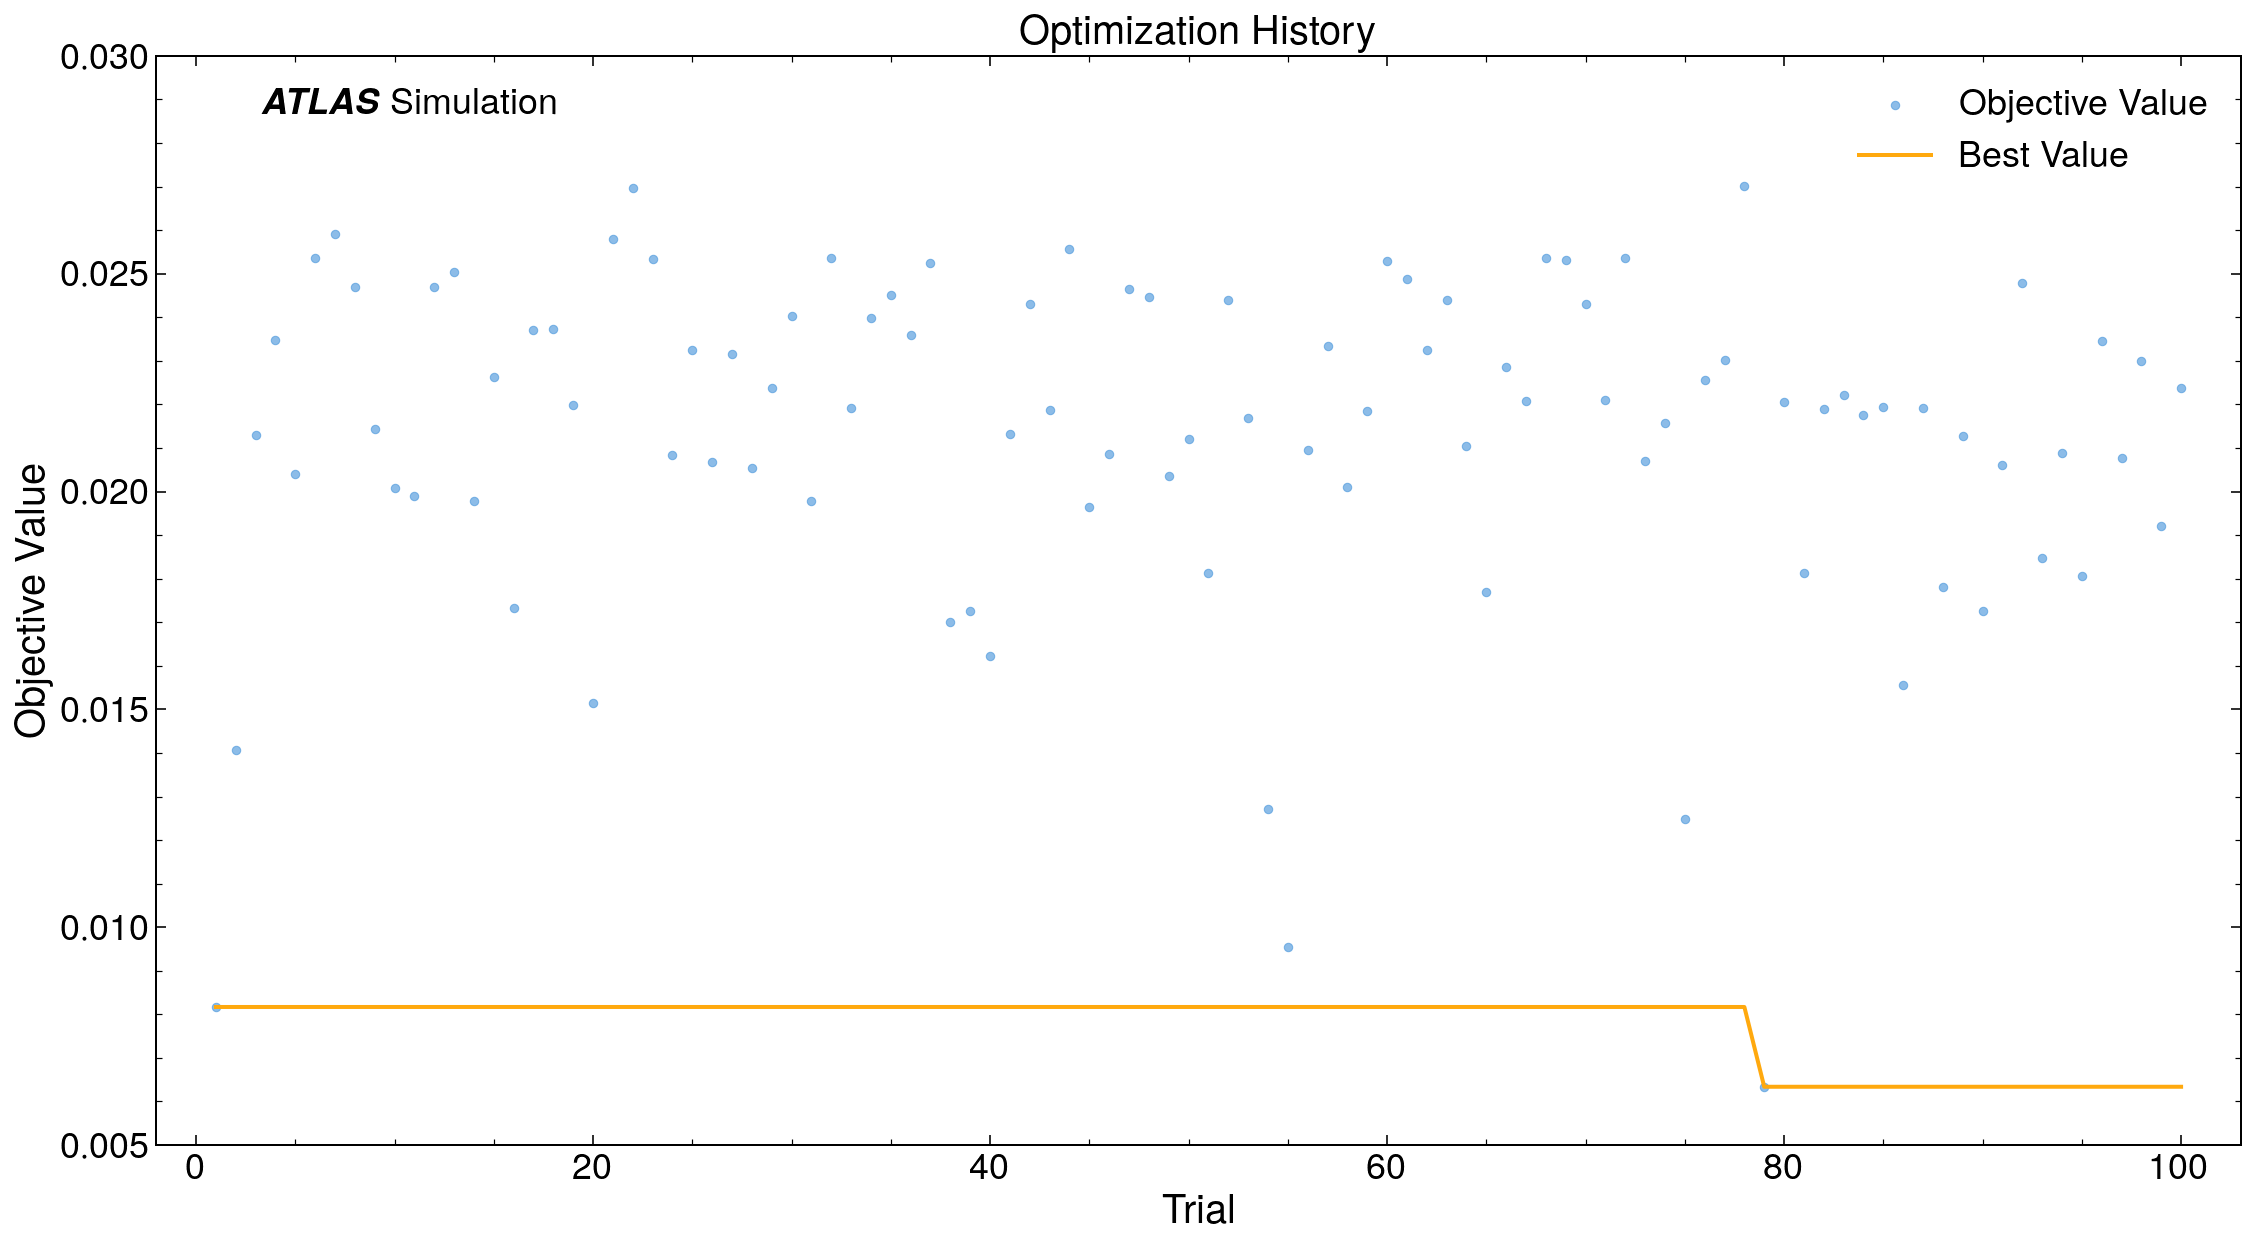

In [12]:
from src.models.plots import plot_optimization_history
from src.visualization.plots import save_figure

fig = plot_optimization_history(trial_df)
save_figure(fig, plots_dir / "optimization_history.png")

### Parameter Importances

Ranked by absolute Spearman correlation with the objective value.

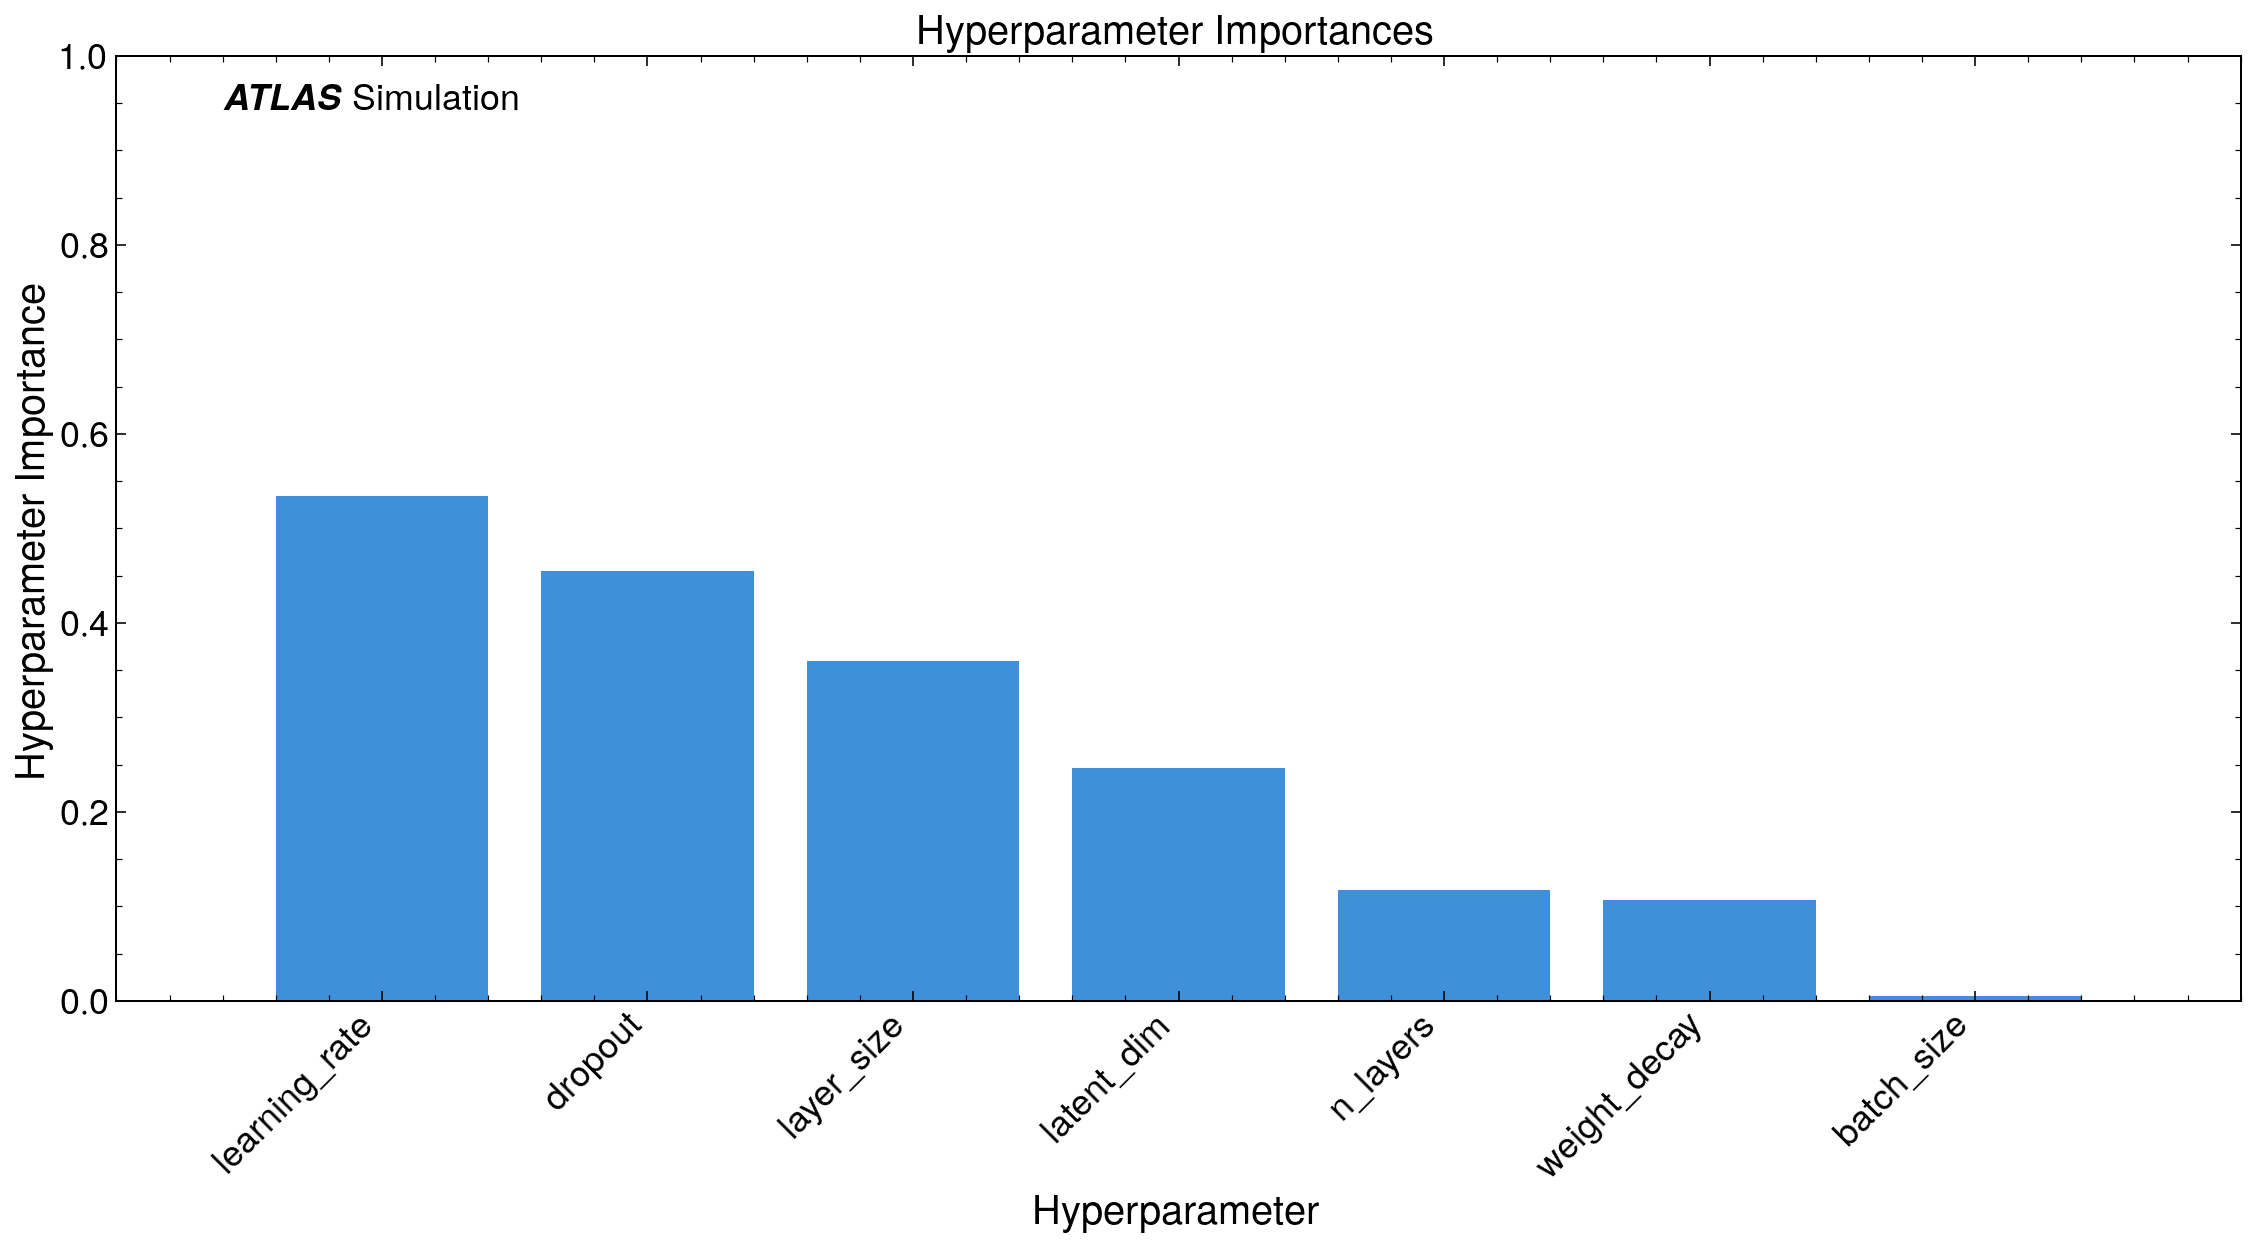

In [13]:
from src.models.plots import plot_hyperparameter_importance

fig = plot_hyperparameter_importance(trial_df)
save_figure(fig, plots_dir / "param_importances.png")

### Contour Plot

Interpolated objective surface for the two most important hyperparameters.

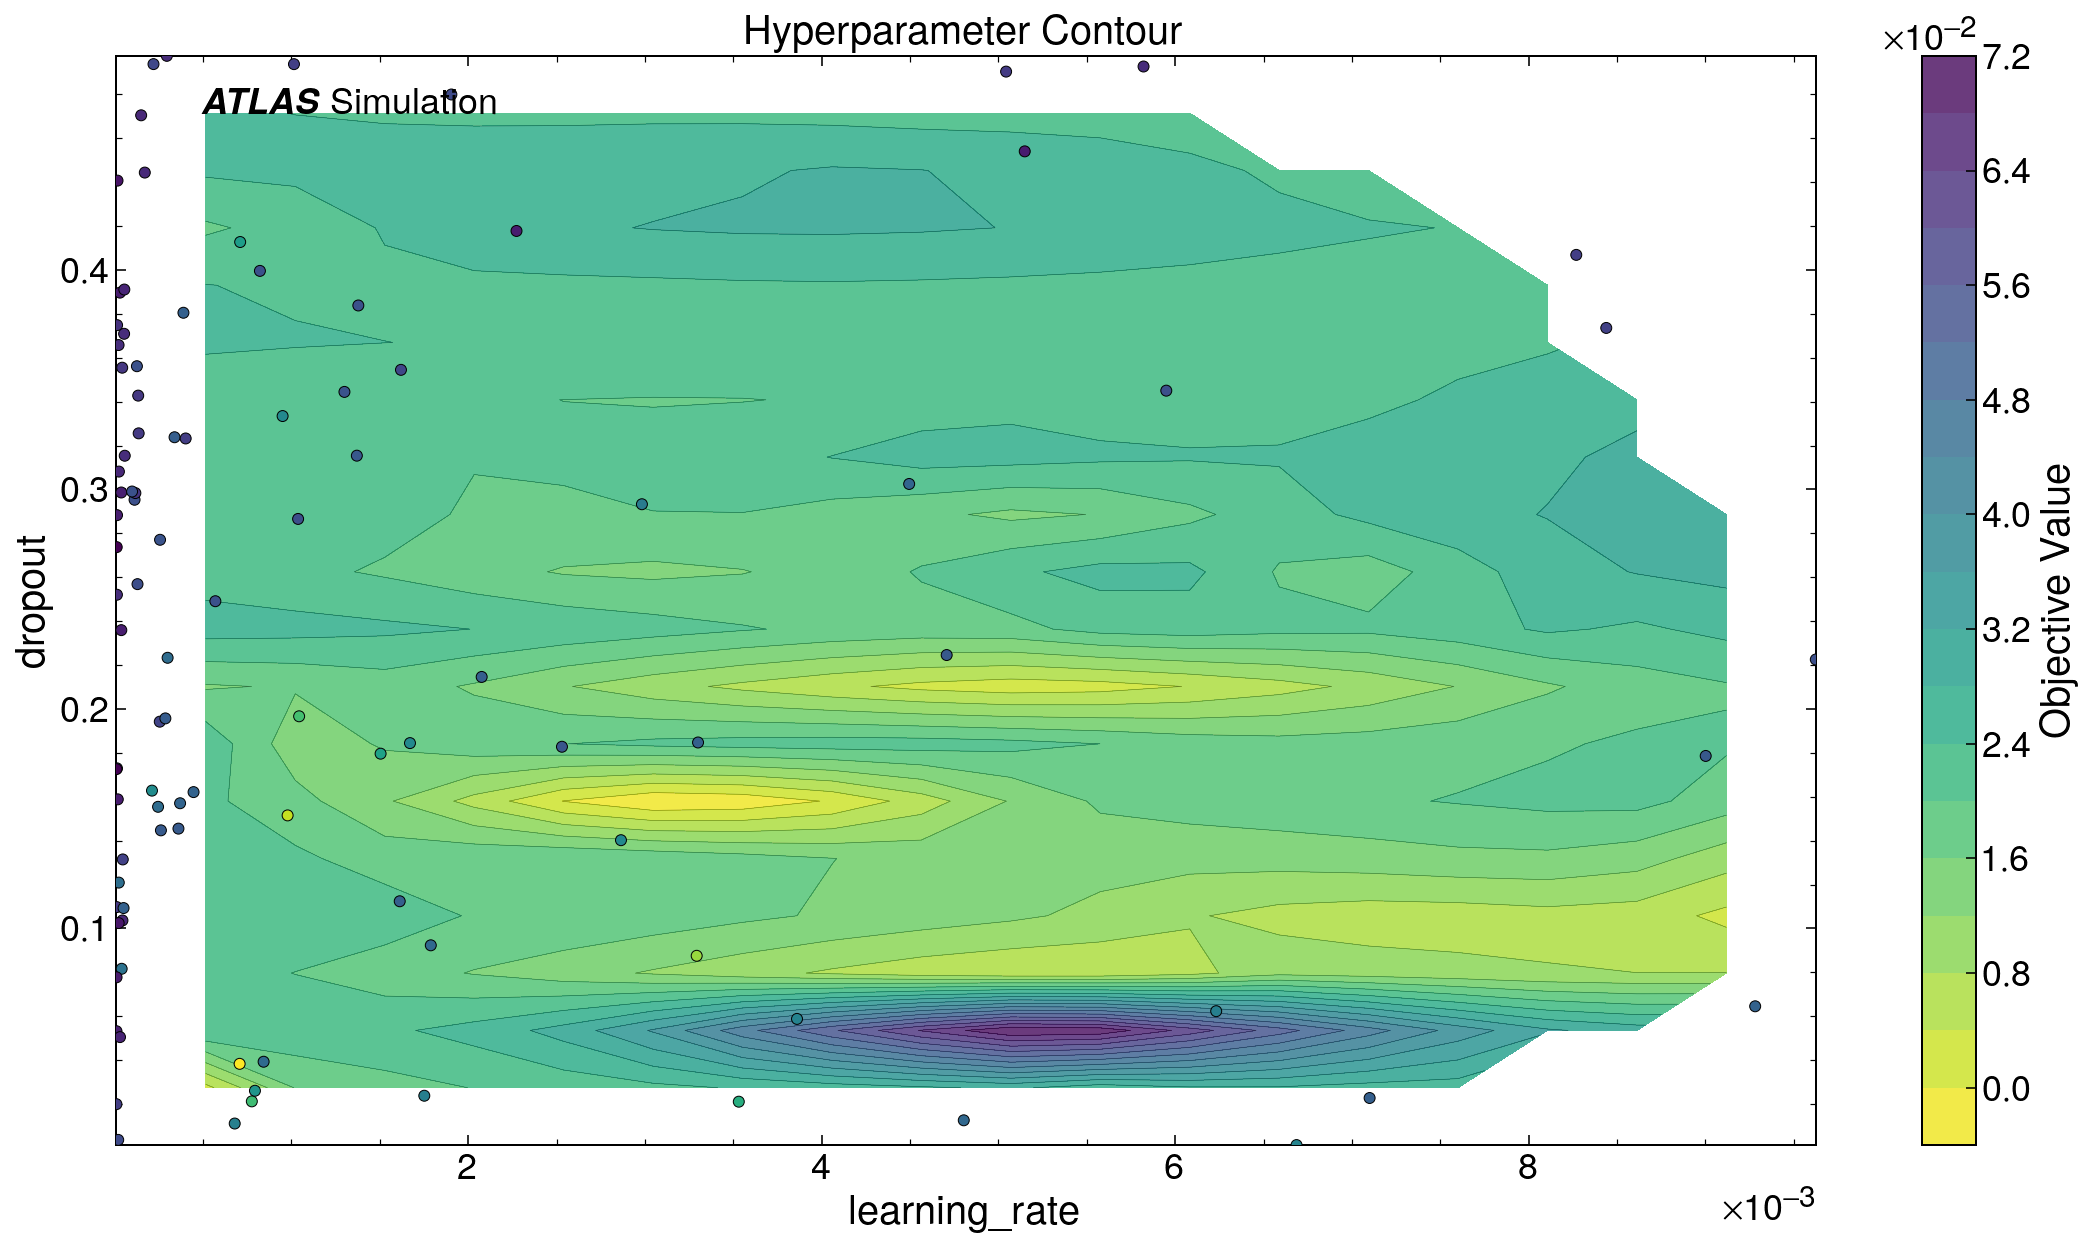

In [14]:
from src.models.plots import plot_hp_contour

fig = plot_hp_contour(trial_df)
save_figure(fig, plots_dir / "contour.png")

### Parallel Coordinate Plot

Each line is a trial, coloured by objective value.

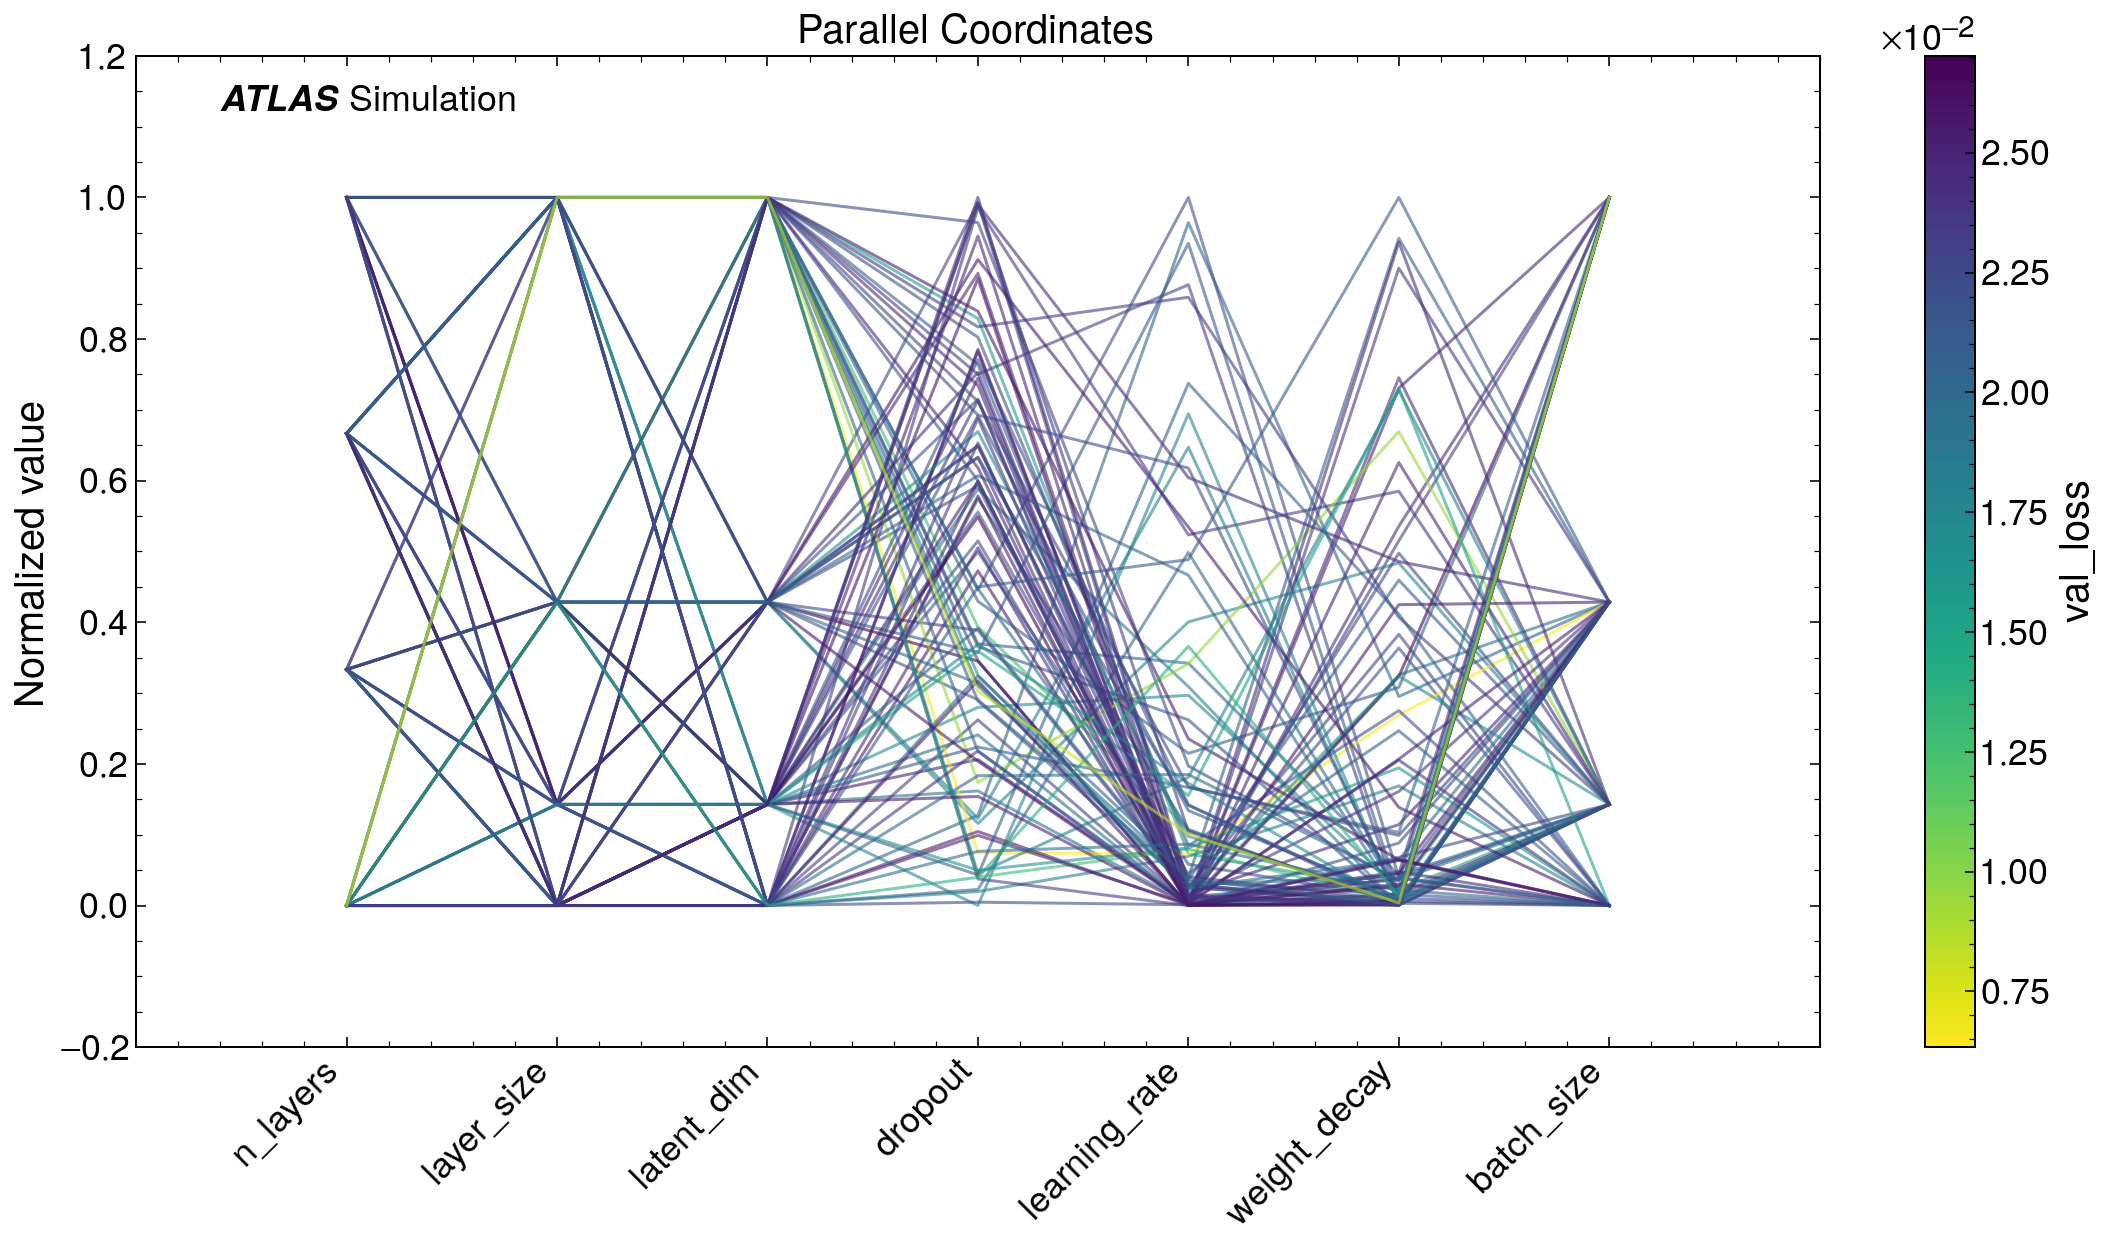

In [15]:
from src.models.plots import plot_parallel_coordinates

fig = plot_parallel_coordinates(trial_df)
save_figure(fig, plots_dir / "parallel_coordinate.png")

### Slice Plot

Marginal effect of each hyperparameter on the objective.

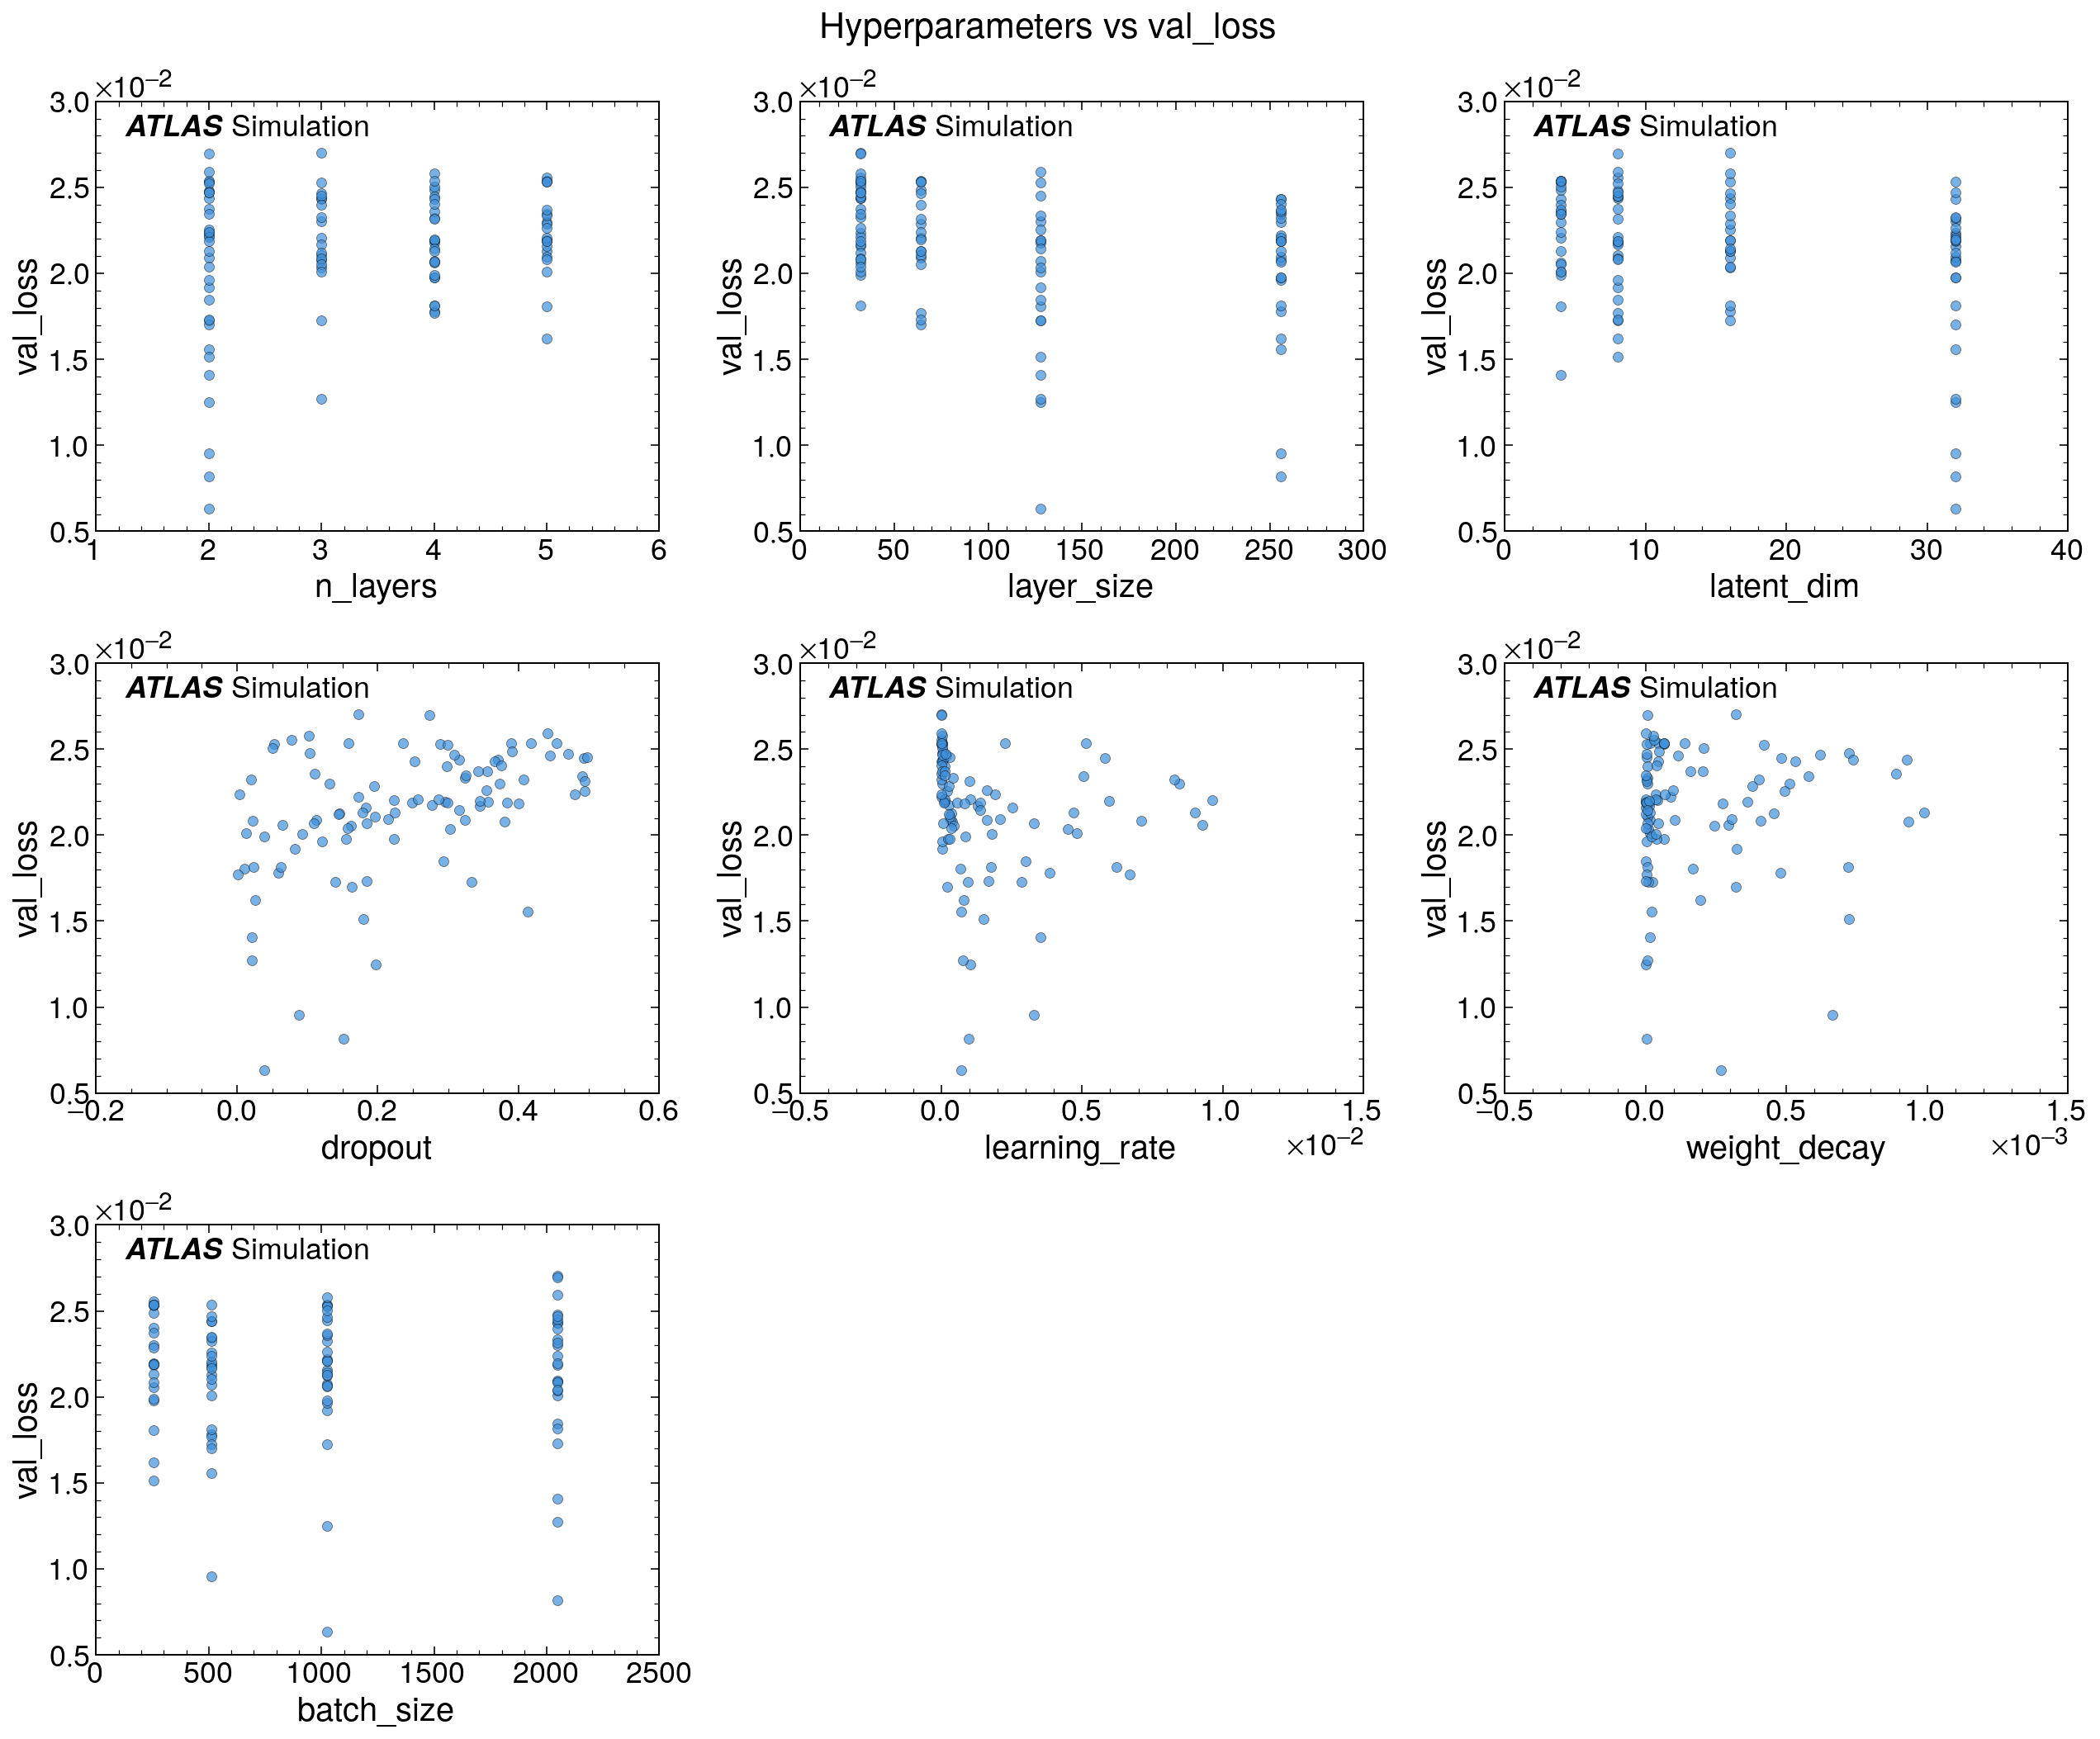

In [16]:
from src.models.plots import plot_hp_vs_objective

fig = plot_hp_vs_objective(trial_df)
save_figure(fig, plots_dir / "slice.png")

## Export Best Parameters

Exporting the best trial's parameters as a Hydra-compatible YAML model config.

```bash
cp <output_path> configs/model/ae_tuned.yaml
uv run python run.py stage=train model=ae_tuned
```

In [17]:
import json
import ray
from src.models.tuning import export_best_config

best_model_config = export_best_config(best_config, model_type)

params_path = models_dir / f"{model_type}_best_tuning.json"
with open(params_path, "w") as f:
    json.dump(best_model_config, f, indent=2)

ray.shutdown()